In [9]:
#COMPLETE DATA CLEANING CODE 


import pandas as pd

# Load dataset
df = pd.read_csv("retail_store_sales.csv")

# View data
print(df.head())
print(df.info())

# -------------------------------
# 1. Remove duplicates
df = df.drop_duplicates()

# -------------------------------
# 2. Handle missing values
print(df.isnull().sum())

# Fill missing discount with 0
df['Discount Applied'] = df['Discount Applied'].fillna(0)

# -------------------------------
# 3. Convert date column
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# -------------------------------
# 4. Fix column names (clean format)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# -------------------------------
# 5. Standardize text columns
df['category'] = df['category'].str.lower().str.strip()
df['payment_method'] = df['payment_method'].str.lower().str.strip()

# -------------------------------
# 6. Create new column (total_spent check)
df['calculated_total'] = df['price_per_unit'] * df['quantity']

# -------------------------------
# 7. Save cleaned dataset
df.to_csv("cleaned_retail_data.csv", index=False)

print("✅ Data Cleaning Completed")

  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3              NaN  
4          

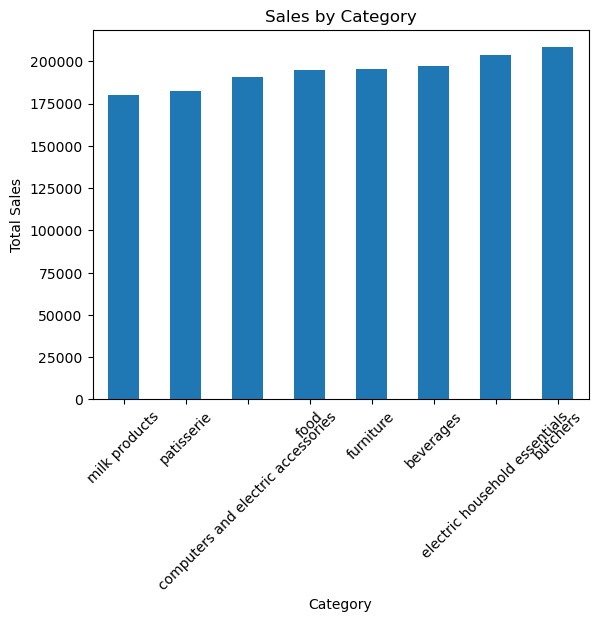

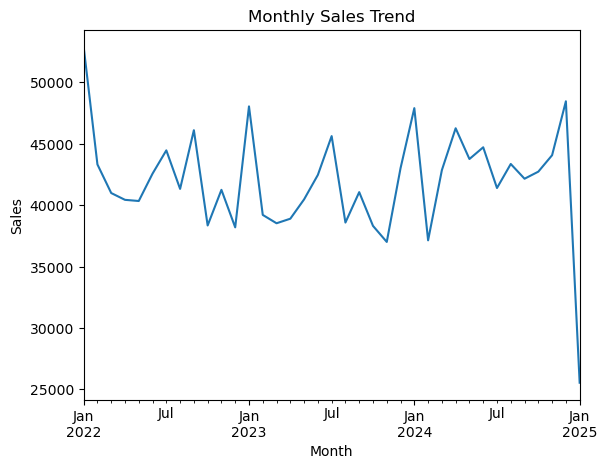

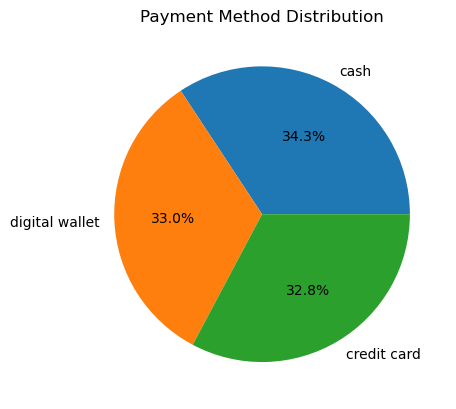

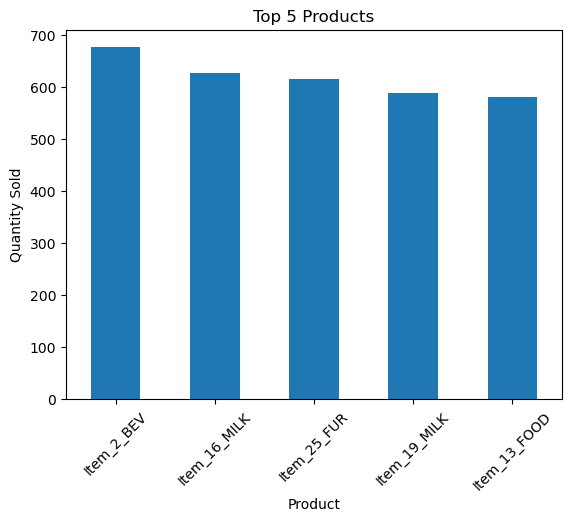

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# CLEAN COLUMN NAMES (VERY IMPORTANT)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# -------------------------------
# 1. Sales by Category
category_sales = df.groupby('category')['total_spent'].sum().sort_values()

plt.figure()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 2. Monthly Sales Trend
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['month'] = df['transaction_date'].dt.to_period('M')

monthly_sales = df.groupby('month')['total_spent'].sum()

plt.figure()
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# -------------------------------
# 3. Payment Method Distribution
payment_counts = df['payment_method'].value_counts()

plt.figure()
payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

# -------------------------------
# 4. Top 5 Products (FIXED ✅)

top_products = df.groupby('item')['quantity'].sum().sort_values(ascending=False).head(5)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 5 Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()